## Data Ingestion

In [ ]:
import pandas as pd
import numpy as np
from sklearn.impute import SimpleImputer

In [ ]:
data = pd.read_csv("/content/drive/MyDrive/FDM/urban_lifestyle_impact_dataset.csv")

In [ ]:
data[data.notnull().all(axis=1)].head(10)

,daily_travel_time,vehicle_ownership,location_type,nearby_industries,green_space_access,home_air_quality,work_location_type,smoker_in_household,noise_pollution_level,use_of_air_purifiers,awareness_level,years_in_location,pollution_exposure_score,risk_category
3,75.5,Car,Semi-Urban,2.0,Moderate,64.4,Remote,False,27.1,False,High,22.0,43.97,Medium
6,76.6,Public Only,Semi-Urban,2.0,High,63.8,Office,False,76.3,False,Low,7.0,41.50,Medium
11,35.7,Public Only,Urban,4.0,Moderate,50.8,Factory,False,44.2,True,Low,11.0,48.27,Medium
13,6.7,Two-wheeler,Semi-Urban,2.0,Moderate,51.4,Office,False,80.0,False,Medium,14.0,25.89,Low
14,10.5,Public Only,Semi-Urban,2.0,Low,58.9,Remote,False,44.5,False,Low,13.0,35.27,Medium
16,24.7,Two-wheeler,Semi-Urban,1.0,Low,68.4,Remote,False,55.8,False,High,27.0,31.40,Medium
17,51.3,Public Only,Rural,0.0,Moderate,62.4,Remote,False,67.0,False,Medium,3.0,18.53,Low
18,26.8,Two-wheeler,Urban,0.0,Moderate,61.8,Factory,False,81.1,True,High,37.0,33.55,Medium
19,16.8,Public Only,Rural,2.0,Moderate,68.0,Factory,True,36.0,True,Low,27.0,34.43,Medium
22,46.4,Two-wheeler,Urban,0.0,Low,54.4,Fieldwork,False,44.7,False,Low,29.0,47.15,Medium


In [ ]:


# data['nearby_industries'].unique()
# data['home_air_quality'].unique()

## Data Exploration

In [ ]:
data.shape

(10000, 14)

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   daily_travel_time         8876 non-null   float64
 1   vehicle_ownership         6836 non-null   object 
 2   location_type             10000 non-null  object 
 3   nearby_industries         9205 non-null   float64
 4   green_space_access        9440 non-null   object 
 5   home_air_quality          10000 non-null  float64
 6   work_location_type        9347 non-null   object 
 7   smoker_in_household       10000 non-null  bool   
 8   noise_pollution_level     10000 non-null  float64
 9   use_of_air_purifiers      10000 non-null  bool   
 10  awareness_level           8985 non-null   object 
 11  years_in_location         9480 non-null   float64
 12  pollution_exposure_score  10000 non-null  float64
 13  risk_category             10000 non-null  object 
dtypes: bool

In [ ]:
num_cols = data.select_dtypes(include=['number']).columns.tolist()
cat_cols = data.select_dtypes(include=['object', 'category']).columns.tolist()

In [ ]:
bool_cols = data.select_dtypes(include=['bool']).columns.tolist()

In [ ]:
num_cols

['daily_travel_time',
 'nearby_industries',
 'home_air_quality',
 'noise_pollution_level',
 'years_in_location',
 'pollution_exposure_score']

In [ ]:
cat_cols

['vehicle_ownership',
 'location_type',
 'green_space_access',
 'work_location_type',
 'awareness_level',
 'risk_category']

In [ ]:
bool_cols

['smoker_in_household', 'use_of_air_purifiers']

In [ ]:
data['location_type'].unique()

array(['Semi-Urban', 'Urban', 'Rural'], dtype=object)

Text(0.5, 1.0, 'Polution across dif location')

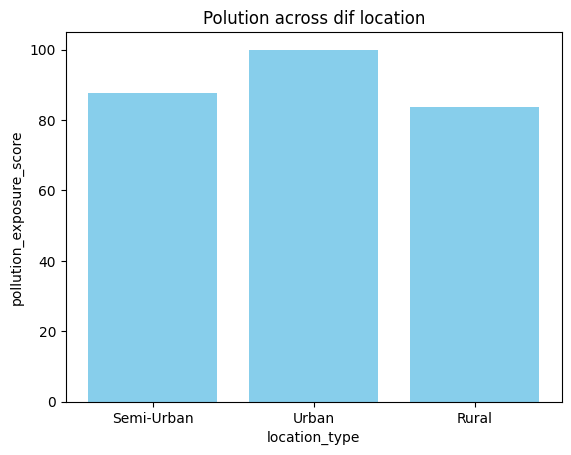

In [ ]:
import matplotlib.pyplot as plt
plt.bar(data['location_type'], data['pollution_exposure_score'], color="skyblue")

plt.xlabel("location_type")
plt.ylabel("pollution_exposure_score")
plt.title("Polution across dif location")

## Handling Missing Data and Duplicates


In [ ]:
data.isna().sum()

,0
daily_travel_time,1124
vehicle_ownership,3164
location_type,0
nearby_industries,795
green_space_access,560
home_air_quality,0
work_location_type,653
smoker_in_household,0
noise_pollution_level,0
use_of_air_purifiers,0


Check the Precentage value.

In [ ]:
(data.isna().sum()/len(data))*100

,0
daily_travel_time,11.24
vehicle_ownership,31.64
location_type,0.00
nearby_industries,7.95
green_space_access,5.60
home_air_quality,0.00
work_location_type,6.53
smoker_in_household,0.00
noise_pollution_level,0.00
use_of_air_purifiers,0.00


In [ ]:
num_imputer = SimpleImputer(strategy='mean')
data[['daily_travel_time','nearby_industries','years_in_location']]=num_imputer.fit_transform(data[['daily_travel_time','nearby_industries','years_in_location']])

In [ ]:
col_imputer = SimpleImputer(strategy='most_frequent')
data[['vehicle_ownership','green_space_access','work_location_type','awareness_level']] = col_imputer.fit_transform(data[['vehicle_ownership','green_space_access','work_location_type','awareness_level']])

In [ ]:
data.duplicated().sum()

np.int64(0)

In [ ]:
data.isna().sum()

,0
daily_travel_time,0
vehicle_ownership,0
location_type,0
nearby_industries,0
green_space_access,0
home_air_quality,0
work_location_type,0
smoker_in_household,0
noise_pollution_level,0
use_of_air_purifiers,0


In [ ]:
#use datnadard scaler for num cols
#use onehot en for cat

data.dtypes

,0
daily_travel_time,float64
vehicle_ownership,object
location_type,object
nearby_industries,float64
green_space_access,object
home_air_quality,float64
work_location_type,object
smoker_in_household,bool
noise_pollution_level,float64
use_of_air_purifiers,bool


## Standardizing & Normalizing Data

we have splitted data and then tasnformed (beacuse we have to get the exact scaler and encoder that has been used in tarining for the integration to tarsnform the user input to get that we have to ge the x varible scaler and encoder

In [ ]:
y = data.iloc[:,13:]
x = data.iloc[:,:12]


In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

num_columns = x.select_dtypes(include=['int64', 'float64']).columns

stdscaler = StandardScaler()

x[num_columns] = stdscaler.fit_transform(data[num_columns])




In [ ]:

import pandas as pd
from sklearn.preprocessing import OneHotEncoder

# Encode x
cat_columns_x = x.select_dtypes(include=['object']).columns
ohe_x = OneHotEncoder(sparse_output=False)
x_encoded_array = ohe_x.fit_transform(x[cat_columns_x])
x_encoded_cols = ohe_x.get_feature_names_out(cat_columns_x)
x_encoded_df = pd.DataFrame(x_encoded_array, columns=x_encoded_cols, index=x.index)
x_final = pd.concat([x.drop(cat_columns_x, axis=1), x_encoded_df], axis=1)

# Encode y
cat_columns_y = y.select_dtypes(include=['object']).columns
ohe_y = OneHotEncoder(sparse_output=False)
y_encoded_array = ohe_y.fit_transform(y[cat_columns_y])
y_encoded_cols = ohe_y.get_feature_names_out(cat_columns_y)
y_encoded_df = pd.DataFrame(y_encoded_array, columns=y_encoded_cols, index=y.index)
y_final = pd.concat([y.drop(cat_columns_y, axis=1), y_encoded_df], axis=1)


In [ ]:
y_final

,risk_category_High,risk_category_Low,risk_category_Medium
0,0.0,0.0,1.0
1,1.0,0.0,0.0
2,0.0,0.0,1.0
3,0.0,0.0,1.0
4,0.0,0.0,1.0
...,...,...,...
9995,0.0,0.0,1.0
9996,0.0,0.0,1.0
9997,0.0,0.0,1.0
9998,0.0,0.0,1.0


In [ ]:
y_final.shape


(10000, 3)

In [ ]:
import joblib

# Save scaler and encoder to Drive
joblib.dump(stdscaler, "/content/drive/MyDrive/scaler.pkl")
joblib.dump(ohe_x, "/content/drive/MyDrive/encoder.pkl")

['/content/drive/MyDrive/encoder.pkl']

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder

y_final["risk_category"] = y_final[["risk_category_High", "risk_category_Low", "risk_category_Medium"]].idxmax(axis=1)

le = LabelEncoder()
y_final = le.fit_transform(y_final["risk_category"])


'''
"risk_category_High" → 0

"risk_category_Low" → 1

"risk_category_Medium" → 2'''
#giving  y cataegrcal varibles a unique number to be used in training since the model can predict a number belongs to a speific class

'\n"risk_category_High" → 0\n\n"risk_category_Low" → 1\n\n"risk_category_Medium" → 2'

In [ ]:
y_final

array([2, 0, 2, ..., 2, 2, 2])

In [ ]:
x_final.head(2)

,daily_travel_time,nearby_industries,home_air_quality,smoker_in_household,noise_pollution_level,use_of_air_purifiers,years_in_location,vehicle_ownership_Car,vehicle_ownership_Public Only,vehicle_ownership_Two-wheeler,...,green_space_access_High,green_space_access_Low,green_space_access_Moderate,work_location_type_Factory,work_location_type_Fieldwork,work_location_type_Office,work_location_type_Remote,awareness_level_High,awareness_level_Low,awareness_level_Medium
0,0.520041,-0.726804,0.348720,False,-0.759256,True,0.655529,0.0,0.0,1.0,...,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
1,-0.157654,2.217515,-1.208279,False,1.969411,False,0.833259,0.0,1.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0


In [ ]:
np.unique(y_final)

array([0, 1, 2])

In [ ]:
y

,risk_category
0,Medium
1,High
2,Medium
3,Medium
4,Medium
...,...
9995,Medium
9996,Medium
9997,Medium
9998,Medium


In [ ]:
x_final.head(2)

,daily_travel_time,nearby_industries,home_air_quality,smoker_in_household,noise_pollution_level,use_of_air_purifiers,years_in_location,vehicle_ownership_Car,vehicle_ownership_Public Only,vehicle_ownership_Two-wheeler,...,green_space_access_High,green_space_access_Low,green_space_access_Moderate,work_location_type_Factory,work_location_type_Fieldwork,work_location_type_Office,work_location_type_Remote,awareness_level_High,awareness_level_Low,awareness_level_Medium
0,0.520041,-0.726804,0.348720,False,-0.759256,True,0.655529,0.0,0.0,1.0,...,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
1,-0.157654,2.217515,-1.208279,False,1.969411,False,0.833259,0.0,1.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0


## model intilazation and training (model: RandomForestClassifier)

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix,classification_report
import seaborn as sns

X_train, X_test, y_train, y_test = train_test_split(x_final, y_final, test_size=0.2, random_state=42)


In [ ]:
clf = RandomForestClassifier(n_estimators=100, max_depth=None, random_state=42)
clf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

used random forest because it's unlikely to overfit over tarining data because it will aggregate multiple decison tress. and also it can leanr non lenear relationships.
less sensitive to otliers is a another plus point.

In [ ]:
y_pred = clf.predict(X_test) #testing

In [ ]:
y_pred

array([2, 2, 2, ..., 2, 2, 2])

In [ ]:
from sklearn.metrics import accuracy_score
accuracy= accuracy_score(y_test,y_pred)
print("Accuracy:",accuracy)

Accuracy: 0.908


In [ ]:
score = clf.score(X_test, y_test)
print("Accuracy:", score)

Accuracy: 0.908


Text(70.72222222222221, 0.5, 'Truth')

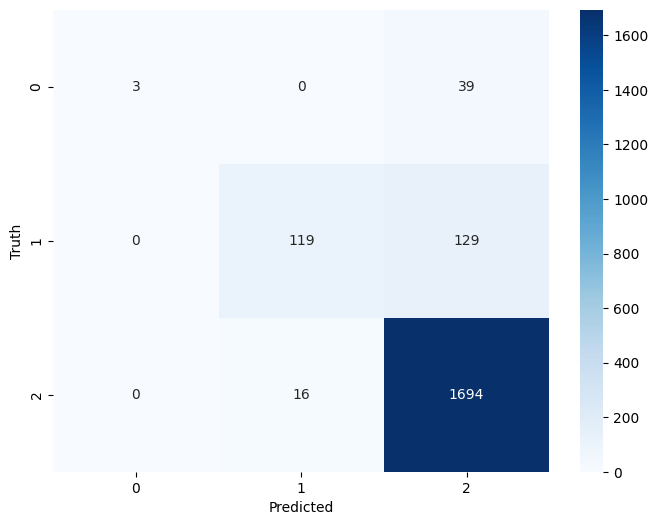

In [ ]:
cf=confusion_matrix(y_test,y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cf,annot=True,fmt='d',cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Truth')

In [ ]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       1.00      0.07      0.13        42
           1       0.88      0.48      0.62       248
           2       0.91      0.99      0.95      1710

    accuracy                           0.91      2000
   macro avg       0.93      0.51      0.57      2000
weighted avg       0.91      0.91      0.89      2000



class 2 dominates the accuracy

# For integration purposes only ❌❌❌


In [ ]:
import joblib

# Save the trained model to Google Drive
model_path = '/content/drive/MyDrive/random_forest_model.pkl'
joblib.dump(clf, model_path)

print("Model saved to Google Drive at:", model_path)


Model saved to Google Drive at: /content/drive/MyDrive/random_forest_model.pkl


In [ ]:
def Standardizer(incomming):

    data = pd.DataFrame([incomming])

    stdscaler = StandardScaler()

   # 1. Scale numeric columns
    stdscaler = StandardScaler()
    num_columns = data.select_dtypes(include=['int64', 'float64']).columns
    data[num_columns] = stdscaler.fit_transform(data[num_columns])

    # 2. Encode categorical columns
    cat_columns = data.select_dtypes(include=['object']).columns
    ohe = OneHotEncoder(sparse_output=False)
    ohe_encoded_array = ohe.fit_transform(data[cat_columns])
    ohe_encoded_cols = ohe.get_feature_names_out(cat_columns)
    ohe_encoded_data = pd.DataFrame(ohe_encoded_array, columns=ohe_encoded_cols, index=data.index)

    #updated data frame with encoded values
    data_final = pd.concat([data.drop(cat_columns, axis=1), ohe_encoded_data], axis=1)
    #res = processed_data.iloc[0].tolist()
    return res


In [ ]:
res = Standardizer({"age": 25, "salary": 5000, "city": "Colombo"})

NameError: name 'res' is not defined

In [ ]:
res

In [ ]:
import pandas as pd
import joblib

In [ ]:
data = pd.DataFrame([{
  "daily_travel_time": 54.9,
  "vehicle_ownership": "Public Only",
  "location_type": "Semi-Urban",
  "nearby_industries": 1.0,
  "green_space_access": "Moderate",
  "home_air_quality": 65.4,
  "work_location_type": "Factory",
  "smoker_in_household": False,
  "noise_pollution_level": 34.9,
  "use_of_air_purifiers": True,
  "awareness_level": "Low",
  "years_in_location": 28.0
}

])

In [ ]:
data.shape

In [ ]:
stdscaler = joblib.load("/content/drive/MyDrive/scaler.pkl")
ohe = joblib.load("/content/drive/MyDrive/encoder.pkl")




num_columns = data.select_dtypes(include=['int64', 'float64']).columns
data[num_columns] = stdscaler.transform(data[num_columns])
bool_columns = data.select_dtypes(include=['bool']).columns

# 2. Encode categorical columns
cat_columns = data.select_dtypes(include=['object']).columns
ohe_encoded_array = ohe.transform(data[cat_columns])
ohe_encoded_cols = ohe.get_feature_names_out(cat_columns)
ohe_encoded_data = pd.DataFrame(ohe_encoded_array, columns=ohe_encoded_cols, index=data.index)

# 3. Combine back into one DataFrame
processed_data = pd.concat([data[num_columns], ohe_encoded_data, data[bool_columns]], axis=1)

In [ ]:
stdscaler = joblib.load("/content/drive/MyDrive/scaler.pkl")
ohe = joblib.load("/content/drive/MyDrive/encoder.pkl")

In [ ]:
'''this is coreccccccccccccccctttttttttt'''
cat_columns_x = data.select_dtypes(include=['object']).columns
x_encoded_array = ohe.transform(data[cat_columns_x])
x_encoded_cols = ohe.get_feature_names_out(cat_columns_x)
x_encoded_df = pd.DataFrame(x_encoded_array, columns=x_encoded_cols, index=data.index)
x_final = pd.concat([x.drop(cat_columns_x, axis=1), x_encoded_df], axis=1)

In [ ]:
x_final.shape

In [ ]:
import joblib

In [ ]:
processed_data.shape

In [ ]:
X_test.head(2)

In [ ]:
processed_data.head(2)